# Large Calibration — Episode-dual n=10 Final Actor

episode-dual Mini Pilotの最終Actor・Cost Criticを完全freezeし、独立した **20 geometry/N × N={2,4,8} × 3 stochastic rollout = 180 rollout** で正式Calibrationを行います。

確認対象は、9 geometryの小規模Calibrationで観測された負相関、false positive、危険scenario見逃しが大きなbankでも再現するかです。各rolloutは初回actionを `Q_C(s₀,a₀)` と実軌道で一致させ、その後もSAC stochastic continuation policyを使います。

各rollout完了時に保存するため、中断後も未完了jobから再開できます。

In [1]:
from pathlib import Path
from copy import deepcopy
import hashlib, json, platform, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

ROOT=Path.cwd().resolve()
if not (ROOT/'uav_safe_marl').is_dir(): ROOT=ROOT.parent
SOURCE_RUN=ROOT/'runs'/'online_cal_n10_episode_dual_dcost6_mps'
SOURCE_CHECKPOINT=SOURCE_RUN/'checkpoints'/'final.pt'
BANK_PATH=ROOT/'runs'/'scenario_diversity_confirmation'/'banks'/'validation_20_per_n.json'
OUTPUT_RUN=ROOT/'runs'/'episode_dual_large_calibration'
ROWS_PATH=OUTPUT_RUN/'large_calibration.jsonl'
META_PATH=OUTPUT_RUN/'collection_metadata.json'
REPEATS=3
STOCHASTIC_SEED_ROOT=930_000
D_COST=6.0
for path in (SOURCE_CHECKPOINT,BANK_PATH,SOURCE_RUN/'resolved_config.json'):
    if not path.exists(): raise FileNotFoundError(path)
OUTPUT_RUN.mkdir(parents=True,exist_ok=True)
print({'source':str(SOURCE_CHECKPOINT),'bank':str(BANK_PATH),'output':str(OUTPUT_RUN),'repeats':REPEATS})

{'source': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_episode_dual_dcost6_mps/checkpoints/final.pt', 'bank': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/scenario_diversity_confirmation/banks/validation_20_per_n.json', 'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/episode_dual_large_calibration', 'repeats': 3}


In [2]:
print({'platform':platform.platform(),'python':platform.python_version(),'torch':torch.__version__,'mps_available':torch.backends.mps.is_available()})
if not torch.backends.mps.is_available(): raise RuntimeError('VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe=torch.ones((128,128),device='mps'); print({'device':str(probe.device),'probe':float((probe@probe).sum().cpu())}); del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 2097152.0}


## 1. Frozen checkpointと独立bankの監査

In [3]:
from uav_safe_marl import build_env,load_config
from uav_safe_marl.evaluation import load_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer
from uav_safe_marl.runners.evaluator import evaluate

scenarios=load_scenario_bank(BANK_PATH)
assert len(scenarios)==60 and {int(s['actual_agent_count']) for s in scenarios}=={2,4,8}
assert all(sum(int(s['actual_agent_count'])==n for s in scenarios)==20 for n in (2,4,8))
overrides=json.loads((SOURCE_RUN/'resolved_config.json').read_text(encoding='utf-8'))
overrides['device']='mps'
overrides['monitoring'].update({'enabled':False,'progress_bar':False,'tensorboard':False,'auto_launch_tensorboard':False,'open_browser':False})
config=load_config(ROOT/'configs'/'full.yaml',overrides=overrides)
assert config.learning.cost_target_n_step==10 and config.training.dual_update_mode=='episode' and config.learning.d_cost==D_COST
checkpoint_sha=hashlib.sha256(SOURCE_CHECKPOINT.read_bytes()).hexdigest()
bank_sha=hashlib.sha256(BANK_PATH.read_bytes()).hexdigest()
metadata={'checkpoint_sha256':checkpoint_sha,'bank_sha256':bank_sha,'repeats':REPEATS,'policy':'stochastic','initial_action_pairing':True,'seed_root':STOCHASTIC_SEED_ROOT}
if META_PATH.exists():
    existing_meta=json.loads(META_PATH.read_text(encoding='utf-8'))
    if existing_meta!=metadata: raise RuntimeError('既存cacheとcheckpoint/bank/条件が一致しません。')
else: META_PATH.write_text(json.dumps(metadata,indent=2),encoding='utf-8')
print({'scenario_count':len(scenarios),'jobs':len(scenarios)*REPEATS,'N_counts':{n:sum(int(s['actual_agent_count'])==n for s in scenarios) for n in (2,4,8)},'max_steps':config.environment.max_steps})

{'scenario_count': 60, 'jobs': 180, 'N_counts': {2: 20, 4: 20, 8: 20}, 'max_steps': 1686}


## 2. Resumable stochastic Calibration collection

jobごとに独立seedを設定するため、中断・再開しても未完了rolloutの乱数条件が変わりません。

In [4]:
def snapshot(module): return {k:v.detach().cpu().clone() for k,v in module.state_dict().items()}
def assert_same(before,module,name):
    if not all(torch.equal(v,module.state_dict()[k].detach().cpu()) for k,v in before.items()): raise RuntimeError(f'{name} changed during calibration')

evaluator=SafeRLTrainer(config,build_env(config),OUTPUT_RUN/'frozen_evaluation')
evaluator.load_checkpoint(SOURCE_CHECKPOINT,resume_training=False)
actor_before=snapshot(evaluator.backend.actor); cost_before=snapshot(evaluator.backend.cost_critics)
rows=[json.loads(line) for line in ROWS_PATH.read_text(encoding='utf-8').splitlines() if line.strip()] if ROWS_PATH.exists() else []
completed={(int(r['repeat']),r['scenario_id']) for r in rows}
jobs=[(repeat,index,scenario) for repeat in range(REPEATS) for index,scenario in enumerate(scenarios)]
pending=[job for job in jobs if (job[0],job[2]['scenario_id']) not in completed]
try:
    with ROWS_PATH.open('a',encoding='utf-8') as stream:
        for repeat,index,scenario in tqdm(pending,desc='Large stochastic calibration',initial=len(completed),total=len(jobs)):
            key=(repeat,scenario['scenario_id'])
            if key in completed: continue
            job_seed=STOCHASTIC_SEED_ROOT+repeat*len(scenarios)+index
            random.seed(job_seed); np.random.seed(job_seed); torch.manual_seed(job_seed); torch.mps.manual_seed(job_seed)
            result=evaluate(evaluator,episodes=1,reset_options={'scenario':scenario},policy_execution_mode='stochastic',pair_initial_action_with_cost=True)
            row=dict(result['episode_metrics'][0])
            if not row['paired_initial_action_matches_rollout'] or not row['paired_initial_nominal_matches_rollout']: raise RuntimeError(f'initial action pairing failed: {key}')
            row.update({'repeat':repeat,'job_seed':job_seed,'training_seed':config.seed,'runtime_hocbf':config.safety.enabled,'calibration_kind':'large_frozen_cost_critic_policy_calibration','critic_continuation_policy':'stochastic_policy','initial_action_conditioning':'same_sample_for_q_and_rollout','coverage_is_empirical_diagnostic':True})
            stream.write(json.dumps(row,ensure_ascii=False)+'\n'); stream.flush(); rows.append(row); completed.add(key)
finally:
    assert_same(actor_before,evaluator.backend.actor,'Actor'); assert_same(cost_before,evaluator.backend.cost_critics,'Cost Critic'); evaluator.env.close()
if len(completed)!=len(jobs): raise RuntimeError(f'incomplete: {len(completed)}/{len(jobs)}')
print({'completed_jobs':len(completed),'frozen_audit':'passed','rows_path':str(ROWS_PATH)})

Large stochastic calibration:   0%|          | 0/180 [00:00<?, ?it/s]

{'completed_jobs': 180, 'frozen_audit': 'passed', 'rows_path': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/episode_dual_large_calibration/large_calibration.jsonl'}


## 3. Rollout-level・scenario-level・N別集計

In [5]:
def rankdata(x):
    x=np.asarray(x,float); order=np.argsort(x,kind='mergesort'); ranks=np.empty(len(x)); i=0
    while i<len(x):
        j=i+1
        while j<len(x) and x[order[j]]==x[order[i]]: j+=1
        ranks[order[i:j]]=(i+j-1)/2+1; i=j
    return ranks
def corr(a,b): return None if len(a)<2 or np.std(a)==0 or np.std(b)==0 else float(np.corrcoef(a,b)[0,1])
def summarize(items,mc_key='mc',q_key='q_ucb'):
    mc=np.asarray([r[mc_key] for r in items],float); q=np.asarray([r[q_key] for r in items],float); actual=mc>D_COST; pred=q>D_COST
    tp=int(np.sum(actual&pred)); fn=int(np.sum(actual&~pred)); tn=int(np.sum(~actual&~pred)); fp=int(np.sum(~actual&pred))
    return {'count':len(items),'mc_mean':float(mc.mean()),'mc_median':float(np.median(mc)),'ucb_mean':float(q.mean()),'bias':float(np.mean(q-mc)),'mae':float(np.mean(abs(q-mc))),'rmse':float(np.sqrt(np.mean((q-mc)**2))),'pearson':corr(mc,q),'spearman':corr(rankdata(mc),rankdata(q)),'coverage':float(np.mean(mc<=q)),'false_negative_rate':fn/max(1,tp+fn),'false_positive_rate':fp/max(1,tn+fp),'confusion':{'tp':tp,'fn':fn,'tn':tn,'fp':fp}}
scenario_rows=[]
for sid in sorted({r['scenario_id'] for r in rows}):
    g=[r for r in rows if r['scenario_id']==sid]
    scenario_rows.append({'scenario_id':sid,'actual_agent_count':int(g[0]['actual_agent_count']),'mc':float(np.mean([r['discounted_episode_cost'] for r in g])),'mc_std':float(np.std([r['discounted_episode_cost'] for r in g])),'q_mean':float(np.mean([r['start_state_cost_mean'] for r in g])),'q_ucb':float(np.mean([r['start_state_cost_ucb'] for r in g])),'pure_intervention':float(np.mean([r['pure_safety_intervention_magnitude'] for r in g])),'success':float(np.mean([r['episode_success'] for r in g]))})
rollout_view=[{'mc':r['discounted_episode_cost'],'q_ucb':r['start_state_cost_ucb']} for r in rows]
report={'definition':'Frozen episode-dual n=10 Actor/Cost Critic; matched initial action and stochastic continuation','design':metadata,'rollout_level':summarize(rollout_view),'scenario_level':summarize(scenario_rows),'by_agent_count':{str(n):summarize([r for r in scenario_rows if r['actual_agent_count']==n]) for n in (2,4,8)},'primary_metrics':{'episode_success_rate':float(np.mean([r['episode_success'] for r in rows])),'separation_violation_rate':sum(r['separation_violation_pair_ticks'] for r in rows)/max(1,sum(r['active_pair_ticks'] for r in rows)),'path_stretch_success_only':float(np.mean([r['path_stretch'] for r in rows if r['path_stretch'] is not None])),'pure_safety_intervention_magnitude':sum(r['pure_intervention_squared_sum'] for r in rows)/max(1,sum(r['active_agent_ticks'] for r in rows)),'communication_load':sum(r['transmitted_bytes'] for r in rows)/max(config.environment.dt_base,sum(r['active_agent_seconds'] for r in rows))}}
(OUTPUT_RUN/'large_calibration_report.json').write_text(json.dumps(report,indent=2),encoding='utf-8')
with (OUTPUT_RUN/'scenario_level.jsonl').open('w',encoding='utf-8') as f:
    for row in scenario_rows: f.write(json.dumps(row)+'\n')
display(report)

{'definition': 'Frozen episode-dual n=10 Actor/Cost Critic; matched initial action and stochastic continuation',
 'design': {'checkpoint_sha256': 'ae80a1b0ada681b71926232cbe9738b3bdbccf44a5e1baa5bbe5f0b75fab1b05',
  'bank_sha256': '51bab465f51e39712734b04d80a6b1956eb8baf4fb185fe12b8822d48939774e',
  'repeats': 3,
  'policy': 'stochastic',
  'initial_action_pairing': True,
  'seed_root': 930000},
 'rollout_level': {'count': 180,
  'mc_mean': 10.17258042932012,
  'mc_median': 1.735224414760955,
  'ucb_mean': 34.639804105957346,
  'bias': 24.467223676637232,
  'mae': 30.873125212237074,
  'rmse': 46.89190305115356,
  'pearson': 0.005777588541476654,
  'spearman': 0.24784754643065976,
  'coverage': 0.7944444444444444,
  'false_negative_rate': 0.0821917808219178,
  'false_positive_rate': 0.6635514018691588,
  'confusion': {'tp': 67, 'fn': 6, 'tn': 36, 'fp': 71}},
 'scenario_level': {'count': 60,
  'mc_mean': 10.172580429320126,
  'mc_median': 1.5054212157786226,
  'ucb_mean': 34.63980410595

## 4. Calibration図と自動判定補助

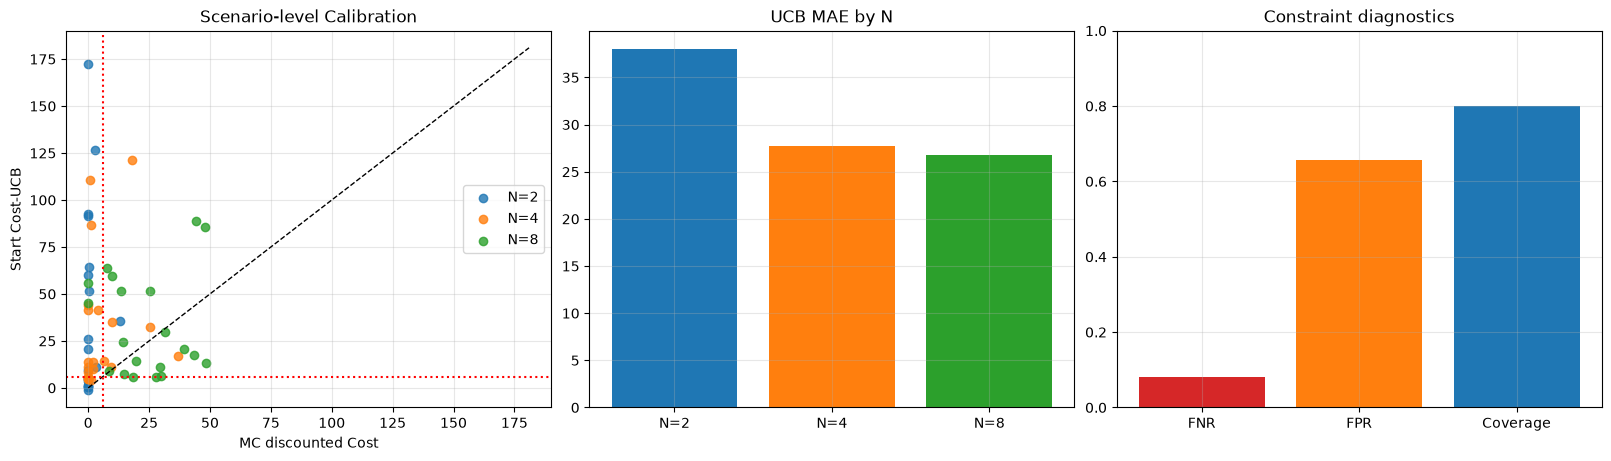

{'decision_aids': {'correlation_positive': True, 'danger_miss_rate_below_0_2': True, 'false_positive_rate_below_0_5': False, 'ucb_coverage_at_least_0_7': True}, 'report': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/episode_dual_large_calibration/large_calibration_report.json', 'figure': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/episode_dual_large_calibration/large_calibration.png'}


In [6]:
colors={2:'tab:blue',4:'tab:orange',8:'tab:green'}
fig,axes=plt.subplots(1,3,figsize=(16,4.5),constrained_layout=True)
for n in (2,4,8):
    g=[r for r in scenario_rows if r['actual_agent_count']==n]
    axes[0].scatter([r['mc'] for r in g],[r['q_ucb'] for r in g],label=f'N={n}',color=colors[n],alpha=.8)
limit=max(max(r['mc'],r['q_ucb']) for r in scenario_rows)*1.05; axes[0].plot([0,limit],[0,limit],'k--',linewidth=1); axes[0].axvline(D_COST,color='red',linestyle=':'); axes[0].axhline(D_COST,color='red',linestyle=':'); axes[0].set(xlabel='MC discounted Cost',ylabel='Start Cost-UCB',title='Scenario-level Calibration'); axes[0].legend()
axes[1].bar(['N=2','N=4','N=8'],[report['by_agent_count'][str(n)]['mae'] for n in (2,4,8)],color=[colors[n] for n in (2,4,8)]); axes[1].set_title('UCB MAE by N')
axes[2].bar(['FNR','FPR','Coverage'],[report['scenario_level']['false_negative_rate'],report['scenario_level']['false_positive_rate'],report['scenario_level']['coverage']],color=['tab:red','tab:orange','tab:blue']); axes[2].set_ylim(0,1); axes[2].set_title('Constraint diagnostics')
for ax in axes: ax.grid(alpha=.3)
figure_path=OUTPUT_RUN/'large_calibration.png'; fig.savefig(figure_path,dpi=170); plt.show()
decision={'correlation_positive':report['scenario_level']['pearson'] is not None and report['scenario_level']['pearson']>0,'danger_miss_rate_below_0_2':report['scenario_level']['false_negative_rate']<0.2,'false_positive_rate_below_0_5':report['scenario_level']['false_positive_rate']<0.5,'ucb_coverage_at_least_0_7':report['scenario_level']['coverage']>=0.7}
print({'decision_aids':decision,'report':str(OUTPUT_RUN/'large_calibration_report.json'),'figure':str(figure_path)})